In [5]:
!pip install bertopic sentence-transformers umap-learn

In [6]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# 讀取之前存的documents
documents_df = pd.read_csv('documents_for_bertopic.csv', index_col=0)
print(documents_df.columns)
print(documents_df.head())

Index(['clean_tokens'], dtype='str')
                                        clean_tokens
0  走 斑馬線 還是 撞 新北 高中生 怒 轟 眼 瞎 啊 影片 瘋傳 駕駛 當下 行為 曝光 ...
1  接受 金門 撞船 案 專案 報告 名稱 民進黨團 明 甲 動 力挺 國家 執法 立委 高金素...
2  開刀 住院 申請 實 支 實 付 見 項目 理賠 氣炸 網 一面 倒 挺 不少 民眾 購買 ...
3  想要 成功 怎麼 運用 專家 投資 絕對 不能 吝嗇 為什麼 管理 稀缺 只有 二十四 小時...
4  台北 某 高中生 打 老師 疑 不滿 訓 影響 上課 突 暴走 比 中指 鎖 喉 揮拳 畫面...


In [7]:
docs = documents_df['clean_tokens'].tolist()

print(len(docs))
print(docs[0])

5764
走 斑馬線 還是 撞 新北 高中生 怒 轟 眼 瞎 啊 影片 瘋傳 駕駛 當下 行為 曝光 開車 前方 駕駛 國中生 罵爆 新北市 日前 發生 起 擦撞 意外 國中生 踩 斑馬線 馬路 竟 轎車 擦撞 學生 右腳 輪胎 輕微 碾過 所幸 未 造成 嚴重 傷害 學生 當下 爆氣 怒 嗆 駕駛 眼 瞎 啊 事發 當下 影片 曝光 頓時 引起 熱議 經常 分享 路人 拍攝 行車 記錄器 所 錄下 荒唐 事跡 粉專 地圖型 行車 紀錄器 分享 平台 昨 日 公開 段 路人 拍攝 影片 見 影片 地點 位於 新北市 中和區 廣福路 廣福路 路口 處 無 號誌 路口 路 只有 綠 白 相間 斑馬線 怎料 國中生 走 斑馬線 馬路 竟 輛 灰色 轎車 擦撞 學生 碾到 腳 頓時 學生 氣炸 怒 轟 眼 瞎 啊 學生 湊近 看見 駕駛 疑似 使用 手機 氣 得 再度 大吼 直播 幹嘛 駕駛 低聲 回道 哪 直播 前面 啊 話 學生 打臉 轟 前面 撞到 要不要 現在 找 學務處 現在 找 學務處 笑 得 出來 好玩 嗎 影片 最後 公開 學生 驗傷單 見 上頭 寫 右 大腿 右膝 右 小腿 挫擦傷 右 足 挫傷 影片 曝光 頓時 引起 熱議 丟臉 守 規矩 年輕人 教 訓 那 句 眼 瞎 啊 罵 得 真 真的 乖 孩子 好學生 有事 先 想到 學務處 出 校門 請 直接 打 找 警察 台灣 需要 更多 優秀 青年 錄影 眼 瞎 太多 所以 知道 馬路 錄影 存證 那邊 質疑 學生 錄影 會不會 太 好笑 有夠 可悲 敢 據理力爭 真的 給予 正向 鼓勵 現在 社會 太多 漠視 違規 導致 違規仔 越來越 囂張 中和 轄區 警方 事 說明 當時 開車 歲 陳姓 駕駛 正 開車 載 孩子 前去 上課 事發 當下 正在 孩子 交代 事情 注意到 前方 國中生 正在 穿越 馬路 造成 擦撞 事故 陳姓 駕駛 酒測值 零 依 路 交通 管理 處罰 條例 條 項 舉發 至於 國中生 送醫 治療 出院 休息 雙方 目前 暫 未 提告


In [8]:
#embedding, BERTopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    language="multilingual",
    calculate_probabilities=False,  # 反正後面要用approximate_distribution，這裡關掉省時間
    verbose=True
)

# Step 1: 初始訓練
topics_raw, _ = topic_model.fit_transform(docs, embeddings)
print(f"初始topic數: {len(set(topics_raw))}")

# Step 2: 縮減到10個，並把結果存到「新的」變數，不要覆蓋topics_raw
topic_model.reduce_topics(docs, nr_topics=10)
topics_reduced = topic_model.topics_   # 縮減後model的真正狀態
print(f"縮減後topic數: {len(set(topics_reduced))}")

# Step 3: 用縮減後的topics_reduced做離群值處理（這是第一次呼叫reduce_outliers，state乾淨）
topics_no_outliers = topic_model.reduce_outliers(docs, topics_reduced, strategy="c-tf-idf")
topic_model.update_topics(docs, topics=topics_no_outliers)

print(topic_model.get_topic_info())
print(f"最終topic數: {len(set(topics_no_outliers))}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/181 [00:00<?, ?it/s]

2026-08-12 11:14:03,604 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-12 11:14:25,740 - BERTopic - Dimensionality - Completed ✓
2026-08-12 11:14:25,741 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-12 11:14:25,831 - BERTopic - Cluster - Completed ✓
2026-08-12 11:14:25,834 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-12 11:14:26,481 - BERTopic - Representation - Completed ✓
2026-08-12 11:14:27,016 - BERTopic - Topic reduction - Reducing number of topics
2026-08-12 11:14:27,022 - BERTopic - Representation - Fine-tuning topics using representation models.


初始topic數: 75


2026-08-12 11:14:27,638 - BERTopic - Representation - Completed ✓
2026-08-12 11:14:27,640 - BERTopic - Topic reduction - Reduced number of topics from 75 to 10
2026-08-12 11:14:28,059 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


縮減後topic數: 10
   Topic  Count              Name  \
0      0   3466  0_台灣_民進黨_國民黨_民眾黨   
1      1    675     1_網友_分享_好吃_許多   
2      2    671     2_中國_經濟_市場_美國   
3      3    390     3_健康_食物_醫師_飲食   
4      4    277     4_公司_蘋果_影片_使用   
5      5    114  5_俄羅斯_烏克蘭_美國_以色列   
6      6     40    6_川普_美國_拜登_共和黨   
7      7     61     7_星座_財運_機會_事業   
8      8     70    8_投資_錢包_生活_有錢人   

                                   Representation  \
0   [台灣, 民進黨, 國民黨, 民眾黨, 立委, 總統, 中國, 選舉, 柯文哲, 賴清德]   
1        [網友, 分享, 好吃, 許多, 編輯, 討論, 責任, 推薦, 使用, 不少]   
2       [中國, 經濟, 市場, 美國, 美元, 公司, 投資, 日本, 全球, 台積電]   
3     [健康, 食物, 醫師, 飲食, 維生素, 血壓, 身體, 攝取, 營養師, 膽固醇]   
4        [公司, 蘋果, 影片, 使用, 用戶, 手機, 功能, 網路, 員工, 詐騙]   
5  [俄羅斯, 烏克蘭, 美國, 以色列, 戰爭, 德國, 普京, 國家, 納瓦爾尼, 哈瑪斯]   
6       [川普, 美國, 拜登, 共和黨, 初選, 總統, 北約, 海莉, 移民, 歐洲]   
7        [星座, 財運, 機會, 事業, 財富, 生肖, 關係, 工作, 得到, 容易]   
8       [投資, 錢包, 生活, 有錢人, 工作, 財富, 朋友, 人生, 理財, 金錢]   

                                 Representative_Docs  
0  [關鍵 少數 接 接 電話 柯文哲 嘆為 立院 龍頭

In [9]:
topic_distr, _ = topic_model.approximate_distribution(docs)
print(topic_distr.shape)  # 這次要確認是 (5764, 10)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:06<00:00,  1.09s/it]

(5764, 9)


這是預期中的正常結果——因為reduce_outliers把原本的Topic -1（離群值）強制併入其他topic之後，這9個topic本身就是最終的完整分類，沒有第10個「離群值」類別了。

In [10]:
for th in [0.02, 0.05, 0.08, 0.1, 0.15]:
    avg_topics = (topic_distr > th).sum(axis=1).mean()
    print(f"threshold={th}: 平均每篇文件涉及 {avg_topics:.2f} 個topics")

threshold=0.02: 平均每篇文件涉及 2.24 個topics
threshold=0.05: 平均每篇文件涉及 1.96 個topics
threshold=0.08: 平均每篇文件涉及 1.76 個topics
threshold=0.1: 平均每篇文件涉及 1.65 個topics
threshold=0.15: 平均每篇文件涉及 1.45 個topics


In [12]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

bertopic_series = pd.Series(topics_no_outliers, index=documents_df.index, name='bertopic_topic')
merged_final = lda_df.join(bertopic_series, how='inner')

print(f"merged筆數: {len(merged_final)}")

lda_labels = merged_final['dominant_topic'].values
bertopic_labels = merged_final['bertopic_topic'].values

ari = adjusted_rand_score(lda_labels, bertopic_labels)
nmi = normalized_mutual_info_score(lda_labels, bertopic_labels)
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

NameError: name 'lda_df' is not defined

In [13]:
import numpy as np
import networkx as nx
from itertools import combinations
from collections import Counter
from networkx.algorithms.community import greedy_modularity_communities

THRESHOLD = 0.05

def get_doc_topics(doc_topic_matrix, threshold=THRESHOLD):
    doc_topics = []
    for row in doc_topic_matrix:
        topics = np.where(row > threshold)[0].tolist()
        doc_topics.append(topics)
    return doc_topics

def build_pmi_network(doc_topics, k_topics, min_weight=1):
    n_docs = len(doc_topics)
    topic_doc_count = Counter()
    pair_doc_count = Counter()

    for topics in doc_topics:
        for t in set(topics):
            topic_doc_count[t] += 1
        for t1, t2 in combinations(sorted(set(topics)), 2):
            pair_doc_count[(t1, t2)] += 1

    G = nx.Graph()
    G.add_nodes_from(range(k_topics))

    for (t1, t2), co_count in pair_doc_count.items():
        if co_count < min_weight:
            continue
        p_t1 = topic_doc_count[t1] / n_docs
        p_t2 = topic_doc_count[t2] / n_docs
        p_t1t2 = co_count / n_docs
        pmi = np.log(p_t1t2 / (p_t1 * p_t2))
        G.add_edge(t1, t2, weight=pmi, raw_count=co_count)

    for t in range(k_topics):
        G.nodes[t]['doc_count'] = topic_doc_count[t]

    return G

# BERTopic topic數是9個（0~8），標籤用topic keyword
bert_topic_labels = {}
for row in topic_model.get_topic_info().itertuples():
    if row.Topic == -1:
        continue
    keywords = row.Representation[:5]
    bert_topic_labels[row.Topic] = f"B{row.Topic}: " + "/".join(keywords)

doc_topics_bert = get_doc_topics(topic_distr, threshold=THRESHOLD)
G_bert = build_pmi_network(doc_topics_bert, k_topics=9)  # 注意這裡是9不是10

print(f"過濾前邊數: {G_bert.number_of_edges()}")

# 過濾負PMI（跟LDA那邊做法一致）
G_bert_filtered = nx.Graph()
G_bert_filtered.add_nodes_from(G_bert.nodes(data=True))
for u, v, d in G_bert.edges(data=True):
    if d['weight'] > 0.05:
        G_bert_filtered.add_edge(u, v, **d)

print(f"過濾後邊數: {G_bert_filtered.number_of_edges()}")

G_bert_filtered = nx.relabel_nodes(G_bert_filtered, bert_topic_labels)

# Community detection
communities_bert = greedy_modularity_communities(G_bert_filtered, weight='weight')
print("\n=== BERTopic Communities ===")
for i, comm in enumerate(communities_bert):
    print(f"Community {i}: {sorted(comm)}")

過濾前邊數: 36
過濾後邊數: 15

=== BERTopic Communities ===
Community 0: ['B1: 網友/分享/好吃/許多/編輯', 'B3: 健康/食物/醫師/飲食/維生素', 'B4: 公司/蘋果/影片/使用/用戶', 'B7: 星座/財運/機會/事業/財富', 'B8: 投資/錢包/生活/有錢人/工作']
Community 1: ['B0: 台灣/民進黨/國民黨/民眾黨/立委', 'B2: 中國/經濟/市場/美國/美元', 'B5: 俄羅斯/烏克蘭/美國/以色列/戰爭', 'B6: 川普/美國/拜登/共和黨/初選']


In [14]:
bertopic_keywords = {}

topic_info = topic_model.get_topic_info()

for topic_id in topic_info["Topic"]:

    if topic_id == -1:
        continue

    words = [
        word
        for word, score in topic_model.get_topic(topic_id)[:15]
    ]

    bertopic_keywords[topic_id] = words

    print(f"\nBERTopic B{topic_id}:")
    print(" | ".join(words))


BERTopic B0:
台灣 | 民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 中國 | 選舉 | 柯文哲 | 賴清德

BERTopic B1:
網友 | 分享 | 好吃 | 許多 | 編輯 | 討論 | 責任 | 推薦 | 使用 | 不少

BERTopic B2:
中國 | 經濟 | 市場 | 美國 | 美元 | 公司 | 投資 | 日本 | 全球 | 台積電

BERTopic B3:
健康 | 食物 | 醫師 | 飲食 | 維生素 | 血壓 | 身體 | 攝取 | 營養師 | 膽固醇

BERTopic B4:
公司 | 蘋果 | 影片 | 使用 | 用戶 | 手機 | 功能 | 網路 | 員工 | 詐騙

BERTopic B5:
俄羅斯 | 烏克蘭 | 美國 | 以色列 | 戰爭 | 德國 | 普京 | 國家 | 納瓦爾尼 | 哈瑪斯

BERTopic B6:
川普 | 美國 | 拜登 | 共和黨 | 初選 | 總統 | 北約 | 海莉 | 移民 | 歐洲

BERTopic B7:
星座 | 財運 | 機會 | 事業 | 財富 | 生肖 | 關係 | 工作 | 得到 | 容易

BERTopic B8:
投資 | 錢包 | 生活 | 有錢人 | 工作 | 財富 | 朋友 | 人生 | 理財 | 金錢


In [18]:
# ============================================================
# Rebuild BERTopic PMI Network
# ============================================================

import numpy as np
import networkx as nx
from collections import Counter
from itertools import combinations

# ------------------------------------------------------------
# 1. 使用 BERTopic 每篇文件的 topic list
# ------------------------------------------------------------

print("doc_topics_bert:")
print(type(doc_topics_bert))
print("Number of documents:", len(doc_topics_bert))
print("First 5 documents:")
print(doc_topics_bert[:5])


# ------------------------------------------------------------
# 2. 建立 PMI network
# ------------------------------------------------------------

def build_pmi_network(doc_topics, k_topics, min_weight=1):

    n_docs = len(doc_topics)

    topic_doc_count = Counter()
    pair_doc_count = Counter()

    # topic 出現次數
    for topics_in_doc in doc_topics:

        unique_topics = set(topics_in_doc)

        for t in unique_topics:
            topic_doc_count[t] += 1

        # topic pair 共現
        for t1, t2 in combinations(sorted(unique_topics), 2):
            pair_doc_count[(t1, t2)] += 1

    # 建立 graph
    G = nx.Graph()

    # 所有 topic 都加入
    G.add_nodes_from(range(k_topics))

    # 計算 PMI
    for (t1, t2), co_count in pair_doc_count.items():

        if co_count < min_weight:
            continue

        p_t1 = topic_doc_count[t1] / n_docs
        p_t2 = topic_doc_count[t2] / n_docs
        p_t1t2 = co_count / n_docs

        pmi = np.log(
            p_t1t2 / (p_t1 * p_t2)
        )

        G.add_edge(
            t1,
            t2,
            weight=float(pmi),
            raw_count=int(co_count)
        )

    # topic document count
    for t in range(k_topics):
        G.nodes[t]["doc_count"] = topic_doc_count[t]

    return G


# ------------------------------------------------------------
# 3. BERTopic topic 數
# ------------------------------------------------------------

k_topics_bert = len(bertopic_keywords)

print("\nNumber of BERTopic topics:", k_topics_bert)


# ------------------------------------------------------------
# 4. 建立完整 PMI network
# ------------------------------------------------------------

G_bertopic_full = build_pmi_network(
    doc_topics_bert,
    k_topics=k_topics_bert,
    min_weight=1
)

print("\n=== BERTopic PMI Network ===")
print("Nodes:", G_bertopic_full.number_of_nodes())
print("Edges:", G_bertopic_full.number_of_edges())


# ------------------------------------------------------------
# 5. PMI > 0.05 filtering
# ------------------------------------------------------------

PMI_THRESHOLD = 0.05

G_bertopic = nx.Graph()

# 保留所有 nodes
G_bertopic.add_nodes_from(G_bertopic_full.nodes(data=True))

# 只保留 PMI > 0.05
for u, v, d in G_bertopic_full.edges(data=True):

    if d["weight"] > PMI_THRESHOLD:

        G_bertopic.add_edge(
            u,
            v,
            weight=d["weight"],
            raw_count=d["raw_count"]
        )

print("\n=== BERTopic PMI Filtering ===")
print("Original edges:", G_bertopic_full.number_of_edges())
print("PMI > 0.05 edges:", G_bertopic.number_of_edges())


# ------------------------------------------------------------
# 6. 印出所有 edges
# ------------------------------------------------------------

print("\n=== BERTopic Edges ===")

for u, v, d in sorted(
    G_bertopic.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
):

    print(
        f"B{u} <-> B{v}: "
        f"PMI={d['weight']:.3f}, "
        f"raw_count={d['raw_count']}"
    )


# ------------------------------------------------------------
# 7. 印出 keywords
# ------------------------------------------------------------

print("\n=== BERTopic Keywords ===")

for topic_id, words in bertopic_keywords.items():

    print(
        f"B{topic_id}: "
        + " | ".join(words[:5])
    )

doc_topics_bert:
<class 'list'>
Number of documents: 5764
First 5 documents:
[[0, 1, 4], [0], [1, 4], [7, 8], [4, 7]]

Number of BERTopic topics: 9

=== BERTopic PMI Network ===
Nodes: 9
Edges: 36

=== BERTopic PMI Filtering ===
Original edges: 36
PMI > 0.05 edges: 15

=== BERTopic Edges ===
B5 <-> B6: PMI=1.546, raw_count=622
B7 <-> B8: PMI=1.158, raw_count=294
B2 <-> B5: PMI=0.821, raw_count=706
B2 <-> B6: PMI=0.727, raw_count=553
B2 <-> B4: PMI=0.351, raw_count=705
B0 <-> B6: PMI=0.332, raw_count=436
B1 <-> B4: PMI=0.279, raw_count=586
B4 <-> B8: PMI=0.242, raw_count=333
B1 <-> B3: PMI=0.205, raw_count=257
B0 <-> B5: PMI=0.193, raw_count=441
B2 <-> B8: PMI=0.165, raw_count=389
B0 <-> B2: PMI=0.129, raw_count=834
B3 <-> B8: PMI=0.126, raw_count=140
B1 <-> B8: PMI=0.109, raw_count=329
B3 <-> B7: PMI=0.093, raw_count=72

=== BERTopic Keywords ===
B0: 台灣 | 民進黨 | 國民黨 | 民眾黨 | 立委
B1: 網友 | 分享 | 好吃 | 許多 | 編輯
B2: 中國 | 經濟 | 市場 | 美國 | 美元
B3: 健康 | 食物 | 醫師 | 飲食 | 維生素
B4: 公司 | 蘋果 | 影片 | 使用 | 用戶
B5

In [19]:
print("BERTopic keywords:")
for topic_id, words in bertopic_keywords.items():
    print(topic_id, ":", " | ".join(words[:5]))

print("\nGraph nodes:")
print(sorted(G_bertopic.nodes()))

print("\nGraph edges:")
for u, v, d in G_bertopic.edges(data=True):
    print(
        f"{u} <-> {v}: "
        f"PMI={d['weight']:.3f}"
    )

BERTopic keywords:
0 : 台灣 | 民進黨 | 國民黨 | 民眾黨 | 立委
1 : 網友 | 分享 | 好吃 | 許多 | 編輯
2 : 中國 | 經濟 | 市場 | 美國 | 美元
3 : 健康 | 食物 | 醫師 | 飲食 | 維生素
4 : 公司 | 蘋果 | 影片 | 使用 | 用戶
5 : 俄羅斯 | 烏克蘭 | 美國 | 以色列 | 戰爭
6 : 川普 | 美國 | 拜登 | 共和黨 | 初選
7 : 星座 | 財運 | 機會 | 事業 | 財富
8 : 投資 | 錢包 | 生活 | 有錢人 | 工作

Graph nodes:
[0, 1, 2, 3, 4, 5, 6, 7, 8]

Graph edges:
0 <-> 2: PMI=0.129
0 <-> 5: PMI=0.193
0 <-> 6: PMI=0.332
1 <-> 4: PMI=0.279
1 <-> 3: PMI=0.205
1 <-> 8: PMI=0.109
2 <-> 4: PMI=0.351
2 <-> 5: PMI=0.821
2 <-> 6: PMI=0.727
2 <-> 8: PMI=0.165
3 <-> 8: PMI=0.126
3 <-> 7: PMI=0.093
4 <-> 8: PMI=0.242
5 <-> 6: PMI=1.546
7 <-> 8: PMI=1.158


In [20]:
print("=== G_bertopic ===")
print("Nodes:", G_bertopic.number_of_nodes())
print("Edges:", G_bertopic.number_of_edges())

print("\nNodes:")
for node in G_bertopic.nodes():
    print(repr(node))

=== G_bertopic ===
Nodes: 9
Edges: 15

Nodes:
0
1
2
3
4
5
6
7
8


In [21]:
for name in dir():
    if "pmi" in name.lower() or "edge" in name.lower():
        print(name)

PMI_THRESHOLD
build_pmi_network


In [22]:
print(build_pmi_network)

<function build_pmi_network at 0x7fcee1a4e980>


In [23]:
import inspect

print(inspect.signature(build_pmi_network))

print(inspect.getsource(build_pmi_network))

(doc_topics, k_topics, min_weight=1)
def build_pmi_network(doc_topics, k_topics, min_weight=1):

    n_docs = len(doc_topics)

    topic_doc_count = Counter()
    pair_doc_count = Counter()

    # topic 出現次數
    for topics_in_doc in doc_topics:

        unique_topics = set(topics_in_doc)

        for t in unique_topics:
            topic_doc_count[t] += 1

        # topic pair 共現
        for t1, t2 in combinations(sorted(unique_topics), 2):
            pair_doc_count[(t1, t2)] += 1

    # 建立 graph
    G = nx.Graph()

    # 所有 topic 都加入
    G.add_nodes_from(range(k_topics))

    # 計算 PMI
    for (t1, t2), co_count in pair_doc_count.items():

        if co_count < min_weight:
            continue

        p_t1 = topic_doc_count[t1] / n_docs
        p_t2 = topic_doc_count[t2] / n_docs
        p_t1t2 = co_count / n_docs

        pmi = np.log(
            p_t1t2 / (p_t1 * p_t2)
        )

        G.add_edge(
            t1,
            t2,
            weight=float(pmi),
            raw_coun

In [24]:
for name in dir():
    if "topic" in name.lower():
        print(name)

BERTopic
G_bertopic
G_bertopic_full
avg_topics
bert_topic_labels
bertopic_keywords
bertopic_series
doc_topics_bert
get_doc_topics
k_topics_bert
topic_distr
topic_id
topic_info
topic_model
topics_no_outliers
topics_raw
topics_reduced


In [25]:
#create BERTopic PMI network
G_bertopic = build_pmi_network(
    doc_topics_bert,
    k_topics=9,
    min_weight=1
)

print("Nodes:", G_bertopic.number_of_nodes())
print("Edges:", G_bertopic.number_of_edges())

Nodes: 9
Edges: 36


In [26]:
print(type(doc_topics_bert))
print(len(doc_topics_bert))
print(doc_topics_bert[:5])

<class 'list'>
5764
[[0, 1, 4], [0], [1, 4], [7, 8], [4, 7]]


In [27]:
#create BERTopic network
G_bertopic = build_pmi_network(
    doc_topics_bert,
    k_topics=9,
    min_weight=1
)

print("=== BERTopic PMI Network ===")
print("Nodes:", G_bertopic.number_of_nodes())
print("Edges:", G_bertopic.number_of_edges())

=== BERTopic PMI Network ===
Nodes: 9
Edges: 36


In [28]:
G_bertopic_filtered = nx.Graph()

G_bertopic_filtered.add_nodes_from(
    G_bertopic.nodes(data=True)
)

for u, v, data in G_bertopic.edges(data=True):

    if data["weight"] > 0.05:

        G_bertopic_filtered.add_edge(
            u,
            v,
            **data
        )

print("=== PMI Filtering ===")
print("原始 edges:", G_bertopic.number_of_edges())
print("PMI > 0.05:", G_bertopic_filtered.number_of_edges())

=== PMI Filtering ===
原始 edges: 36
PMI > 0.05: 15


In [29]:
#community
from networkx.algorithms.community import greedy_modularity_communities

communities_bertopic = list(
    greedy_modularity_communities(
        G_bertopic_filtered,
        weight="weight"
    )
)

community_map_bertopic = {}

for i, community in enumerate(communities_bertopic):
    for topic in community:
        community_map_bertopic[topic] = i

print("=== BERTopic Communities ===")

for i, community in enumerate(communities_bertopic):
    print(f"Community {i}: {sorted(community)}")

=== BERTopic Communities ===
Community 0: [1, 3, 4, 7, 8]
Community 1: [0, 2, 5, 6]


In [30]:
#filtered graph
import networkx as nx

# ==========================================
# PMI > 0.05
# ==========================================

G_bertopic_filtered = nx.Graph()

# 保留所有 nodes
G_bertopic_filtered.add_nodes_from(
    G_bertopic.nodes(data=True)
)

# 保留 PMI > 0.05 的 edges
for u, v, data in G_bertopic.edges(data=True):

    if data["weight"] > 0.05:

        G_bertopic_filtered.add_edge(
            u,
            v,
            **data
        )

print("=== BERTopic Network ===")
print("Nodes:", G_bertopic_filtered.number_of_nodes())
print("Edges:", G_bertopic_filtered.number_of_edges())

=== BERTopic Network ===
Nodes: 9
Edges: 15


In [ ]:
#degree centrality
degree_bertopic = nx.degree_centrality(
    G_bertopic_filtered
)

print("=== BERTopic Degree Centrality ===")

for topic, value in sorted(
    degree_bertopic.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"B{topic}: {value:.3f}")

=== BERTopic Degree Centrality ===
B2: 0.625
B8: 0.625
B0: 0.375
B1: 0.375
B3: 0.375
B4: 0.375
B5: 0.375
B6: 0.375
B7: 0.250


In [31]:
import matplotlib.font_manager as fm

fonts = fm.findSystemFonts()

for font in fonts:
    if any(x in font.lower() for x in [
        "noto",
        "cjk",
        "wqy",
        "chinese",
        "simsun",
        "ming",
        "hei"
    ]):
        print(font)

/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc


In [32]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc"

# 建立 font properties
font_prop = fm.FontProperties(fname=font_path)

print(font_prop.get_name())

Noto Sans CJK JP


Font: Noto Sans CJK JP

=== BERTopic Network ===
Nodes: 9
Edges: 15

=== Degree Centrality ===
B2: 0.625
B8: 0.625
B0: 0.375
B1: 0.375
B3: 0.375
B4: 0.375
B5: 0.375
B6: 0.375
B7: 0.250


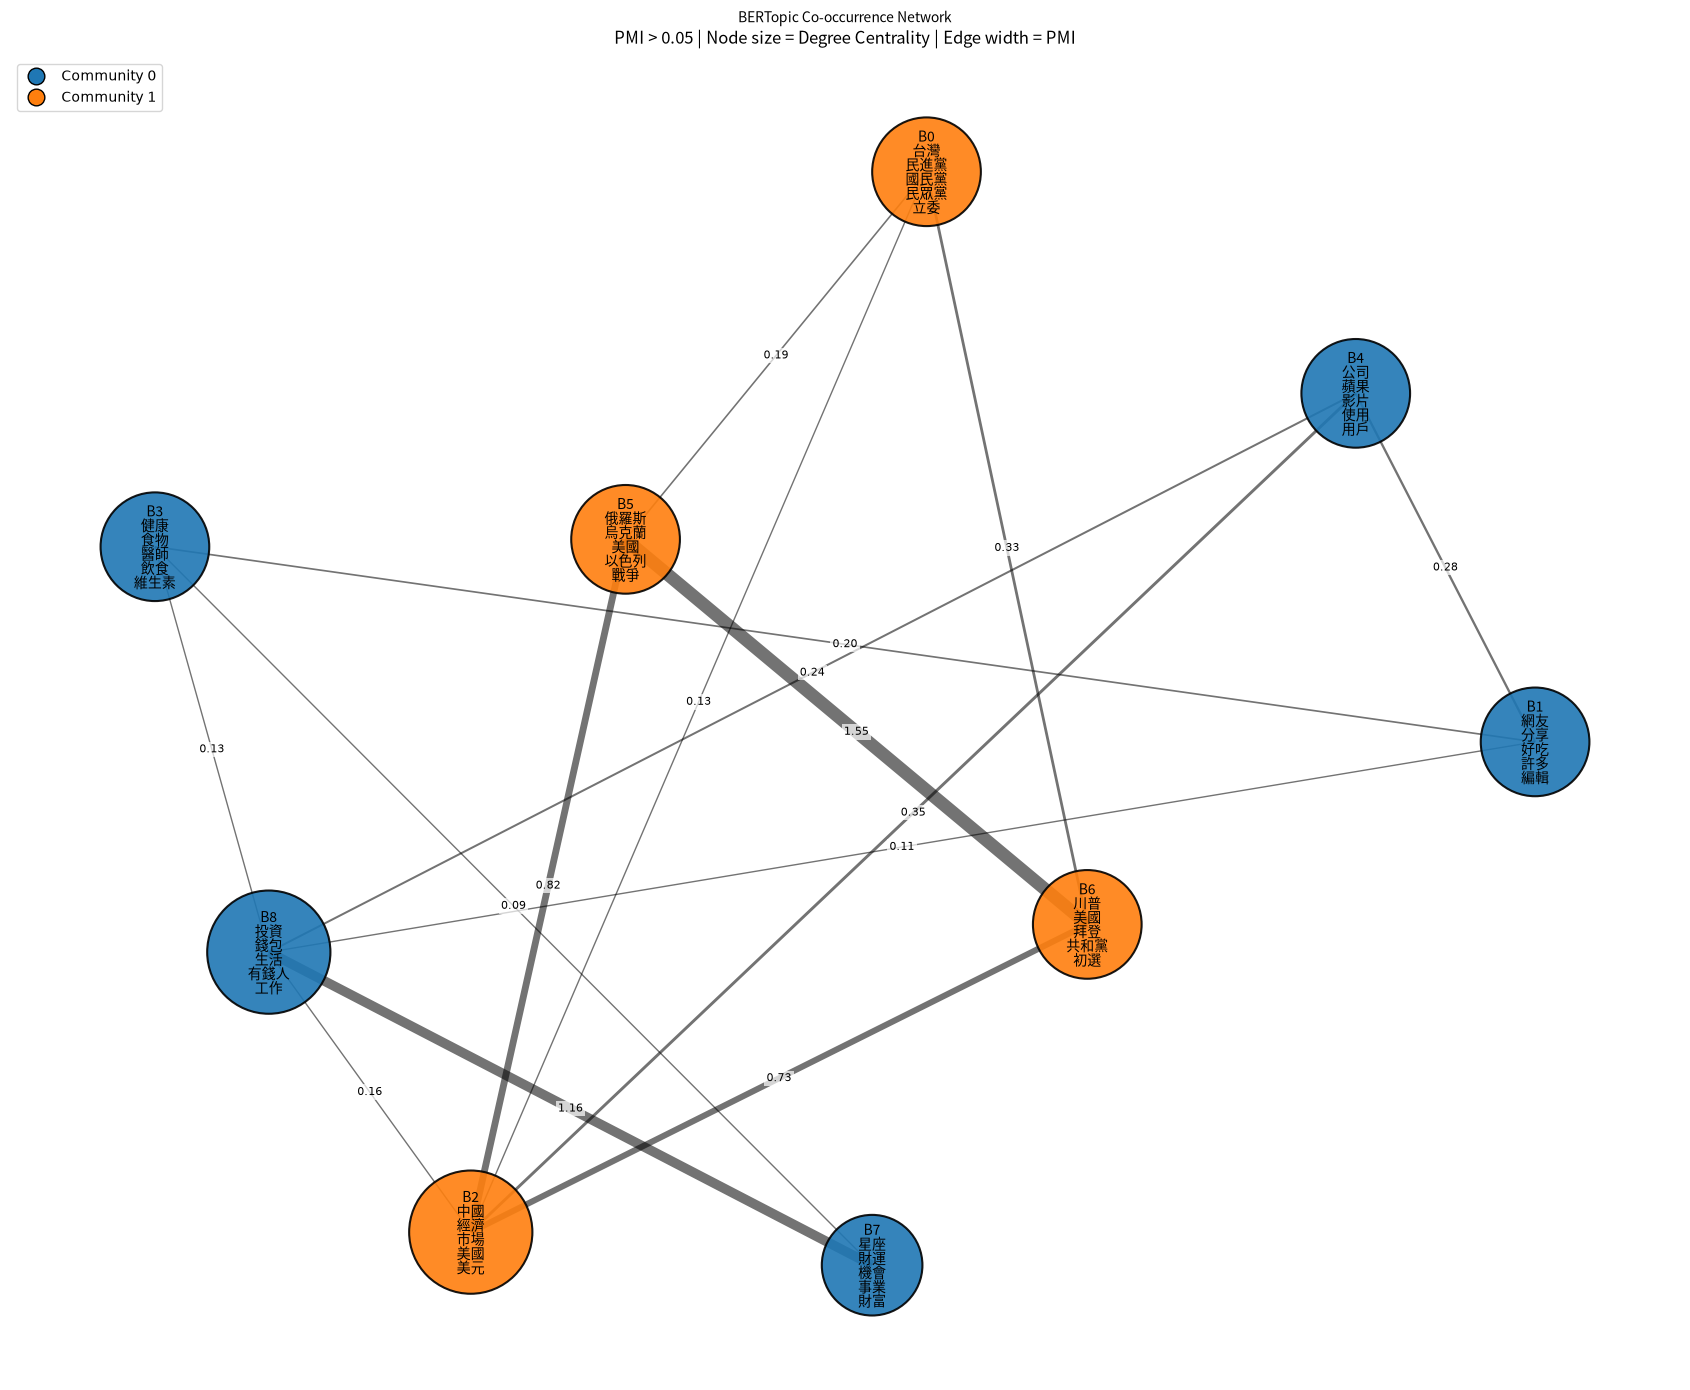


圖已成功儲存
BERTopic_network_PMI005.png
BERTopic_network_PMI005.pdf


In [33]:
# ============================================================
# BERTopic Co-occurrence Network Visualization
# PMI > 0.05
# 中文字型修正版
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx


# ============================================================
# 1. 中文字型
# ============================================================

font_path = "/home/yuli6752/.local/share/fonts/NotoSansCJK-Regular.ttc"

font_prop = fm.FontProperties(
    fname=font_path
)

print("Font:", font_prop.get_name())


# ============================================================
# 2. 確認 graph
# ============================================================

print("\n=== BERTopic Network ===")
print("Nodes:", G_bertopic_filtered.number_of_nodes())
print("Edges:", G_bertopic_filtered.number_of_edges())


# ============================================================
# 3. Degree Centrality
# ============================================================

degree_bertopic = nx.degree_centrality(
    G_bertopic_filtered
)

print("\n=== Degree Centrality ===")

for topic, value in sorted(
    degree_bertopic.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"B{topic}: {value:.3f}")


# ============================================================
# 4. Layout
# ============================================================

pos = nx.spring_layout(
    G_bertopic_filtered,
    seed=42,
    weight="weight",
    k=2.2
)


# ============================================================
# 5. Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 14)
)


# ============================================================
# 6. Community colors
# ============================================================

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

node_colors = []

for node in G_bertopic_filtered.nodes():

    community_id = community_map_bertopic[node]

    node_colors.append(
        colors[
            community_id % len(colors)
        ]
    )


# ============================================================
# 7. Node size
# ============================================================

node_sizes = []

for node in G_bertopic_filtered.nodes():

    size = (
        3500
        + degree_bertopic[node] * 7000
    )

    node_sizes.append(size)


# ============================================================
# 8. Edge width = PMI
# ============================================================

edge_widths = []

for u, v, data in G_bertopic_filtered.edges(data=True):

    pmi = data["weight"]

    edge_widths.append(
        max(1.0, pmi * 6)
    )


# ============================================================
# 9. Draw edges
# ============================================================

nx.draw_networkx_edges(
    G_bertopic_filtered,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=0.55
)


# ============================================================
# 10. Draw nodes
# ============================================================

nx.draw_networkx_nodes(
    G_bertopic_filtered,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.90,
    edgecolors="black",
    linewidths=1.5
)


# ============================================================
# 11. 中文 keywords
# ============================================================

for topic_id in G_bertopic_filtered.nodes():

    # 取得 keywords
    words = bertopic_keywords[topic_id]

    # 只取前 5 個
    top_words = words[:5]

    # 建立文字
    label = (
        f"B{topic_id}\n"
        + "\n".join(top_words)
    )

    # Node position
    x, y = pos[topic_id]

    # ========================================================
    # 使用 matplotlib ax.text
    # 直接指定 FontProperties
    # ========================================================

    ax.text(
        x,
        y,
        label,
        fontsize=10,
        fontweight="bold",
        fontproperties=font_prop,
        ha="center",
        va="center",
        color="black"
    )


# ============================================================
# 12. PMI labels on edges
# ============================================================

for u, v, data in G_bertopic_filtered.edges(data=True):

    x1, y1 = pos[u]
    x2, y2 = pos[v]

    # PMI
    pmi = data["weight"]

    # edge midpoint
    x_mid = (x1 + x2) / 2
    y_mid = (y1 + y2) / 2

    ax.text(
        x_mid,
        y_mid,
        f"{pmi:.2f}",
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.7,
            pad=1.5
        )
    )


# ============================================================
# 13. Title
# ============================================================

ax.set_title(
    "BERTopic Co-occurrence Network",
    fontsize=22,
    fontweight="bold",
    fontproperties=font_prop,
    pad=25
)


# Subtitle
ax.text(
    0.5,
    1.01,
    "PMI > 0.05 | Node size = Degree Centrality | Edge width = PMI",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    fontproperties=font_prop
)


# ============================================================
# 14. Community legend
# ============================================================

legend_handles = []

for community_id in sorted(
    set(community_map_bertopic.values())
):

    handle = plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=12,
        markerfacecolor=colors[
            community_id % len(colors)
        ],
        markeredgecolor="black",
        label=f"Community {community_id}"
    )

    legend_handles.append(handle)


ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True
)


# ============================================================
# 15. Remove axes
# ============================================================

ax.axis("off")


# ============================================================
# 16. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 17. Save PNG
# ============================================================

plt.savefig(
    "BERTopic_network_PMI005.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 18. Save PDF
# ============================================================

plt.savefig(
    "BERTopic_network_PMI005.pdf",
    bbox_inches="tight"
)


# ============================================================
# 19. Show
# ============================================================

plt.show()


print("\n================================")
print("圖已成功儲存")
print("================================")
print("BERTopic_network_PMI005.png")
print("BERTopic_network_PMI005.pdf")

In [39]:
print("=== BERTopic variables ===")

print("\nbertopic_keywords:")
print(type(bertopic_keywords))
print("number of topics:", len(bertopic_keywords))

print("\ntopics_raw:")
print(type(topics_raw))
print("length:", len(topics_raw))

print("\ntopics_reduced:")
print(type(topics_reduced))
print("length:", len(topics_reduced))

print("\ndoc_topics_bert:")
print(type(doc_topics_bert))
print("length:", len(doc_topics_bert))

print("\nG_bertopic:")
print(type(G_bertopic))
print(
    "Nodes:", 
    G_bertopic.number_of_nodes()
)
print(
    "Edges:", 
    G_bertopic.number_of_edges()
)

print("\ncommunity_map_bertopic:")
print(type(community_map_bertopic))
print(community_map_bertopic)

=== BERTopic variables ===

bertopic_keywords:
<class 'dict'>
number of topics: 9

topics_raw:
<class 'list'>
length: 5764

topics_reduced:
<class 'list'>
length: 5764

doc_topics_bert:
<class 'list'>
length: 5764

G_bertopic:
<class 'networkx.classes.graph.Graph'>
Nodes: 9
Edges: 36

community_map_bertopic:
<class 'dict'>
{1: 0, 3: 0, 4: 0, 7: 0, 8: 0, 0: 1, 2: 1, 5: 1, 6: 1}


In [36]:
print("\n=== Shapes / lengths ===")

for name in [
    "topics",
    "topics_raw",
    "topics_reduced",
    "doc_topics_bert"
]:

    obj = globals().get(name)

    if obj is not None:
        try:
            print(name, "→", len(obj))
        except:
            print(name, "→ no len()")


=== Shapes / lengths ===
topics_raw → 5764
topics_reduced → 5764
doc_topics_bert → 5764


In [40]:
# ============================================================
# Step 5A：LDA vs BERTopic Topic-level Comparison
# ============================================================

import pandas as pd
import numpy as np

# LDA dominant topic
lda_df_compare = pd.read_csv(
    "lda_dominant_topic.csv",
    index_col=0
)

lda_topics_compare = (
    lda_df_compare["dominant_topic"]
    .astype(int)
    .to_numpy()
)

# BERTopic reduced topic
bert_topics_compare = np.array(
    topics_reduced
).astype(int)

print("LDA documents:", len(lda_topics_compare))
print("BERTopic documents:", len(bert_topics_compare))

assert len(lda_topics_compare) == len(bert_topics_compare)

print("✓ Document alignment OK")

LDA documents: 5764
BERTopic documents: 5764
✓ Document alignment OK


In [41]:
# ============================================================
# Step 5B：LDA × BERTopic Topic Overlap
# ============================================================

topic_overlap = pd.crosstab(
    pd.Series(
        lda_topics_compare,
        name="LDA"
    ),
    pd.Series(
        bert_topics_compare,
        name="BERTopic"
    )
)

print("=== LDA × BERTopic Topic Overlap ===")

display(topic_overlap)

=== LDA × BERTopic Topic Overlap ===


BERTopic,-1,0,1,2,3,4,5,6,7,8
LDA,,,,,,,,,,
1,126,7,311,0,5,4,0,0,0,0
2,118,112,24,0,212,0,0,0,0,1
3,46,1027,0,1,2,0,1,1,0,0
4,269,373,1,2,4,15,1,1,0,0
5,150,340,0,85,0,4,76,26,0,0
6,52,79,4,6,0,1,7,7,0,0
7,429,416,39,17,5,26,1,0,13,14
8,99,185,1,31,24,9,0,0,0,0
9,89,180,36,7,0,4,0,0,15,2


In [42]:
# ============================================================
# Step 5C：LDA → BERTopic Percentage
# ============================================================

topic_overlap_pct = (
    topic_overlap
    .div(topic_overlap.sum(axis=1), axis=0)
    * 100
)

topic_overlap_pct = topic_overlap_pct.round(2)

print("=== LDA → BERTopic Topic Distribution (%) ===")

display(topic_overlap_pct)

=== LDA → BERTopic Topic Distribution (%) ===


BERTopic,-1,0,1,2,3,4,5,6,7,8
LDA,,,,,,,,,,
1,27.81,1.55,68.65,0.00,1.10,0.88,0.00,0.00,0.00,0.00
2,25.27,23.98,5.14,0.00,45.40,0.00,0.00,0.00,0.00,0.21
3,4.27,95.27,0.00,0.09,0.19,0.00,0.09,0.09,0.00,0.00
4,40.39,56.01,0.15,0.30,0.60,2.25,0.15,0.15,0.00,0.00
5,22.03,49.93,0.00,12.48,0.00,0.59,11.16,3.82,0.00,0.00
6,33.33,50.64,2.56,3.85,0.00,0.64,4.49,4.49,0.00,0.00
7,44.69,43.33,4.06,1.77,0.52,2.71,0.10,0.00,1.35,1.46
8,28.37,53.01,0.29,8.88,6.88,2.58,0.00,0.00,0.00,0.00
9,26.73,54.05,10.81,2.10,0.00,1.20,0.00,0.00,4.50,0.60


In [44]:
# ============================================================
# Step 4D: Final Topic / Community Interpretation Table
# ============================================================

comparison_rows = [

    {
        "Model": "LDA",
        "Community": "C0",
        "Topics": "T5, T6, T7, T9, T10",
        "Semantic Interpretation":
            "Lifestyle, Economy & International Affairs"
    },

    {
        "Model": "LDA",
        "Community": "C1",
        "Topics": "T3, T4, T8",
        "Semantic Interpretation":
            "Politics, Government & Public Affairs"
    },

    {
        "Model": "LDA",
        "Community": "C2",
        "Topics": "T1, T2",
        "Semantic Interpretation":
            "Lifestyle, Food & Health"
    },

    {
        "Model": "BERTopic",
        "Community": "C0",
        "Topics": "B1, B3, B4, B7, B8",
        "Semantic Interpretation":
            "Lifestyle, Health, Technology & Personal Finance"
    },

    {
        "Model": "BERTopic",
        "Community": "C1",
        "Topics": "B0, B2, B5, B6",
        "Semantic Interpretation":
            "Politics, Economy & International Affairs"
    }
]

interpretation_df = pd.DataFrame(comparison_rows)

print("=== LDA vs BERTopic: Community Interpretation ===")
display(interpretation_df)

=== LDA vs BERTopic: Community Interpretation ===


,Model,Community,Topics,Semantic Interpretation
0,LDA,C0,"T5, T6, T7, T9, T10","Lifestyle, Economy & International Affairs"
1,LDA,C1,"T3, T4, T8","Politics, Government & Public Affairs"
2,LDA,C2,"T1, T2","Lifestyle, Food & Health"
3,BERTopic,C0,"B1, B3, B4, B7, B8","Lifestyle, Health, Technology & Personal Finance"
4,BERTopic,C1,"B0, B2, B5, B6","Politics, Economy & International Affairs"


In [45]:
import pandas as pd
import numpy as np

# ============================================================
# Step 5A-0：讀取 LDA dominant topic
# ============================================================

lda_file = "lda_dominant_topic.csv"

lda_df_compare = pd.read_csv(lda_file, index_col=0)

print("=== LDA dominant topic ===")
print(lda_df_compare.head())
print("shape:", lda_df_compare.shape)
print("columns:", lda_df_compare.columns.tolist())

=== LDA dominant topic ===
   dominant_topic
0               4
1               3
2               9
3               7
4               4
shape: (5764, 1)
columns: ['dominant_topic']


In [46]:
#Step 5：LDA vs BERTopic Topic-level Comparison
# ============================================================
# Step 5A：LDA × BERTopic Topic Overlap
# ============================================================

lda_topics_for_compare = lda_df_compare["dominant_topic"].to_numpy()

bert_topics_for_compare = np.array(topics_reduced)

print("LDA documents:", len(lda_topics_for_compare))
print("BERTopic documents:", len(bert_topics_for_compare))

assert len(lda_topics_for_compare) == len(bert_topics_for_compare), \
    "LDA 與 BERTopic 文件數量不一致！"

# 建立 LDA × BERTopic cross-tabulation
topic_overlap = pd.crosstab(
    pd.Series(lda_topics_for_compare, name="LDA"),
    pd.Series(bert_topics_for_compare, name="BERTopic")
)

print("\n=== LDA × BERTopic Topic Overlap ===")
display(topic_overlap)

LDA documents: 5764
BERTopic documents: 5764

=== LDA × BERTopic Topic Overlap ===


BERTopic,-1,0,1,2,3,4,5,6,7,8
LDA,,,,,,,,,,
1,126,7,311,0,5,4,0,0,0,0
2,118,112,24,0,212,0,0,0,0,1
3,46,1027,0,1,2,0,1,1,0,0
4,269,373,1,2,4,15,1,1,0,0
5,150,340,0,85,0,4,76,26,0,0
6,52,79,4,6,0,1,7,7,0,0
7,429,416,39,17,5,26,1,0,13,14
8,99,185,1,31,24,9,0,0,0,0
9,89,180,36,7,0,4,0,0,15,2


In [47]:
# ============================================================
# Step 5B: Best BERTopic match for each LDA topic
# ============================================================

lda_bert_rows = []

for lda_topic in topic_overlap.index:

    row = topic_overlap.loc[lda_topic]

    best_bert_topic = row.idxmax()
    overlap_count = row.max()

    lda_total = row.sum()

    overlap_percent = (
        overlap_count / lda_total * 100
        if lda_total > 0 else 0
    )

    lda_bert_rows.append({
        "LDA Topic": f"T{lda_topic}",
        "Best BERTopic": f"B{best_bert_topic}",
        "Overlap Documents": int(overlap_count),
        "Overlap (%)": round(overlap_percent, 2)
    })

lda_bert_match_df = pd.DataFrame(lda_bert_rows)

print("=== Best LDA → BERTopic Matches ===")
display(lda_bert_match_df)

=== Best LDA → BERTopic Matches ===


,LDA Topic,Best BERTopic,Overlap Documents,Overlap (%)
0,T1,B1,311,68.65
1,T2,B3,212,45.40
2,T3,B0,1027,95.27
3,T4,B0,373,56.01
4,T5,B0,340,49.93
5,T6,B0,79,50.64
6,T7,B-1,429,44.69
7,T8,B0,185,53.01
8,T9,B0,180,54.05
9,T10,B2,264,42.51


In [50]:
# ============================================================
# Step 5C-0：建立 LDA Topic Keywords
# ============================================================

lda_topic_keywords = {
    1: ['網友', '分享', '好吃', '使用', '許多', '編輯', '推薦', '討論', '責任', '料理',
        '發文', '完整', '真的', '不少', '臉書'],

    2: ['健康', '食物', '醫師', '身體', '飲食', '維生素', '建議', '地區', '疾病', '研究',
        '影響', '天氣', '幫助', '血壓', '水果'],

    3: ['民進黨', '國民黨', '民眾黨', '立委', '總統', '選舉', '柯文哲', '賴清德', '國會',
        '立法院', '台灣', '支持', '韓國瑜', '黨團', '大選'],

    4: ['發生', '發現', '警方', '事件', '人員', '調查', '影片', '男子', '金門', '進行',
        '目前', '學生', '法院', '導致', '要求'],

    5: ['中國', '台灣', '美國', '經濟', '國家', '政府', '兩岸', '關係', '總統', '政治',
        '政策', '大陸', '國際', '中共', '德國'],

    6: ['日本', '台灣', '大學', '美國', '歷史', '旅遊', '國家', '香港', '國際', '旅客',
        '世界', '川普', '泰國', '航空', '日圓'],

    7: ['網友', '什麼', '工作', '許多', '台灣', '這樣', '大家', '知道', '生活', '真的',
        '孩子', '開始', '還是', '不少', '覺得'],

    8: ['政府', '台灣', '相關', '安全', '陳建仁', '社會', '要求', '民眾', '規定', '業者',
        '政策', '進行', '台電', '機關', '行政院'],

    9: ['工作', '申請', '獎金', '民眾', '春節', '金額', '今年', '刮刮樂', '紅包', '補助',
        '責任', '銀行', '財富', '年終', '期間'],

    10: ['公司', '市場', '投資', '美元', '全球', '企業', '台積電', '產業', '去年', '今年',
         '科技', '技術', '成長', '半導體', '員工']
}

print("=== LDA Topic Keywords ===")

for topic_id, words in lda_topic_keywords.items():
    print(f"T{topic_id}: " + " | ".join(words[:10]))

=== LDA Topic Keywords ===
T1: 網友 | 分享 | 好吃 | 使用 | 許多 | 編輯 | 推薦 | 討論 | 責任 | 料理
T2: 健康 | 食物 | 醫師 | 身體 | 飲食 | 維生素 | 建議 | 地區 | 疾病 | 研究
T3: 民進黨 | 國民黨 | 民眾黨 | 立委 | 總統 | 選舉 | 柯文哲 | 賴清德 | 國會 | 立法院
T4: 發生 | 發現 | 警方 | 事件 | 人員 | 調查 | 影片 | 男子 | 金門 | 進行
T5: 中國 | 台灣 | 美國 | 經濟 | 國家 | 政府 | 兩岸 | 關係 | 總統 | 政治
T6: 日本 | 台灣 | 大學 | 美國 | 歷史 | 旅遊 | 國家 | 香港 | 國際 | 旅客
T7: 網友 | 什麼 | 工作 | 許多 | 台灣 | 這樣 | 大家 | 知道 | 生活 | 真的
T8: 政府 | 台灣 | 相關 | 安全 | 陳建仁 | 社會 | 要求 | 民眾 | 規定 | 業者
T9: 工作 | 申請 | 獎金 | 民眾 | 春節 | 金額 | 今年 | 刮刮樂 | 紅包 | 補助
T10: 公司 | 市場 | 投資 | 美元 | 全球 | 企業 | 台積電 | 產業 | 去年 | 今年


In [53]:
# ============================================================
# Step 6A：Final LDA vs BERTopic Comparison
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# LDA results
# ------------------------------------------------------------

lda_n_topics = 10
lda_n_docs = 5764
lda_avg_topics = 1.00

lda_n_edges = 7
lda_n_communities = 3
lda_largest_community = 5

lda_avg_purity = 69.03
lda_largest_topic_share = 18.70


# ------------------------------------------------------------
# BERTopic results
# ------------------------------------------------------------

bert_n_topics = 9
bert_n_docs = 5764
bert_avg_topics = 1.96

bert_n_edges = 15
bert_n_communities = 2
bert_largest_community = 5

bert_largest_topic_share = 27.43


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

final_comparison = pd.DataFrame({

    "Metric": [
        "Number of topics",
        "Number of documents",
        "Average topics per document",
        "Network edges (PMI > 0.05)",
        "Number of communities",
        "Largest community (topics)",
        "Average topic purity (%)",
        "Largest topic share (%)",
        "ARI",
        "NMI"
    ],

    "LDA": [
        lda_n_topics,
        lda_n_docs,
        lda_avg_topics,
        lda_n_edges,
        lda_n_communities,
        lda_largest_community,
        lda_avg_purity,
        lda_largest_topic_share,
        "—",
        "—"
    ],

    "BERTopic": [
        bert_n_topics,
        bert_n_docs,
        bert_avg_topics,
        bert_n_edges,
        bert_n_communities,
        bert_largest_community,
        "N/A",
        bert_largest_topic_share,
        0.1597,
        0.3465
    ]
})

print("=== Final LDA vs BERTopic Comparison ===")

display(final_comparison)

=== Final LDA vs BERTopic Comparison ===


,Metric,LDA,BERTopic
0,Number of topics,10,9
1,Number of documents,5764,5764
2,Average topics per document,1.0,1.96
3,Network edges (PMI > 0.05),7,15
4,Number of communities,3,2
5,Largest community (topics),5,5
6,Average topic purity (%),69.03,N/A
7,Largest topic share (%),18.7,27.43
8,ARI,—,0.1597
9,NMI,—,0.3465
